# COGS 109 Final Project: Predicting Sleep Quality from Wearable Multisensor Data

**Team Members:** Anthony Mitine, Harshatha Prasanna, Yuxing Liu

## Introduction
Wearable devices provide a non-invasive way to monitor sleep and daily activity, but transforming raw physiological and movement data into meaningful sleep quality measures remains a challenge. In this project, we use the MMASH dataset, which includes participant sleep records, actigraphy data, heart rate, beat-to-beat interval data, activity logs, questionnaire scores, and demographic information.

Our cleaned analysis dataset contains **n = 21 observations** after excluding one participant with incomplete data, and we use **p = 6 predictors**: age, BMI, average heart rate, total steps, mean vector magnitude, and heavy activity events. Our goal is to predict a continuous sleep quality score from wearable and behavioral features. Since the dataset does not include clinical sleep staging like REM duration, our sleep quality score is derived from available sleep-related variables such as total sleep time, efficiency, wake after sleep onset, number of awakenings, and sleep fragmentation index. We also examine whether daytime activity level is associated with sleep quality.

### Hypothesis

Hypothesis: Participants with higher daytime physical activity (higher `total_steps`, higher `mean_vector_mag`, and more `heavy_activity_events`) will have higher Sleep Quality Scores.

Null hypothesis: Daytime physical activity is not associated with the Sleep Quality Score.

This hypothesis ties directly to the features used in modeling and will be evaluated using cross-validated prediction error and the direction of the fitted coefficients.

In [1]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

### Data Wrangling & Aggregation
Iterating through the `data/user_*` directories to extract and aggregate daytime features and sleep target variables for each of the 22 users.

In [2]:
base_path = 'data'
compiled_data = []

# Loop through all 22 user folders
for i in range(1, 23):
    user_folder = f"user_{i}"
    user_path = os.path.join(base_path, user_folder)
    
    if not os.path.exists(user_path):
        continue
        
    user_dict = {'user_id': i}
    
    # Load User Info
    try:
        user_info = pd.read_csv(os.path.join(user_path, 'user_info.csv'))
        user_dict['age'] = user_info['Age'].values[0]
        user_dict['gender'] = user_info['Gender'].values[0]
        user_dict['bmi'] = user_info['Weight'].values[0] / ((user_info['Height'].values[0]/100)**2)
    except:
        pass

    # Load Sleep Data 
    try:
        sleep_df = pd.read_csv(os.path.join(user_path, 'sleep.csv'))
        user_dict['total_sleep_time'] = sleep_df['Total Sleep Time (TST)'].values[0]
        user_dict['latency_efficiency'] = sleep_df['Efficiency'].values[0]
        user_dict['waso'] = sleep_df['Wake After Sleep Onset (WASO)'].values[0]
        user_dict['awakenings'] = sleep_df['Number of Awakenings'].values[0]
        user_dict['sleep_frag_index'] = sleep_df['Sleep Fragmentation Index'].values[0]
    except:
        pass

    # Aggregate Actigraph Data 
    try:
        act_df = pd.read_csv(os.path.join(user_path, 'Actigraph.csv'))
        # Average daytime HR and total steps
        user_dict['avg_hr'] = act_df['HR'].mean()
        user_dict['total_steps'] = act_df['Steps'].sum()
        user_dict['mean_vector_mag'] = act_df['Vector Magnitude'].mean()
    except:
        pass
    
    # Aggregate Activity Log 
    try:
        activity_df = pd.read_csv(os.path.join(user_path, 'Activity.csv'))
        heavy_acts = activity_df[activity_df['Activity'] == 6]
        user_dict['heavy_activity_events'] = len(heavy_acts)
    except:
        pass
        
    compiled_data.append(user_dict)

# Create dataframe
df = pd.DataFrame(compiled_data)
df.head()

,user_id,age,gender,bmi,total_sleep_time,latency_efficiency,waso,awakenings,sleep_frag_index,avg_hr,total_steps,mean_vector_mag,heavy_activity_events
0,1,29,M,22.758307,144.0,87.27,21.0,9.0,19.091,84.719383,13625,42.201145,4
1,2,27,M,28.367524,244.0,73.49,84.0,18.0,20.616,74.532023,12415,37.210992,3
2,3,34,M,23.120624,351.0,79.23,89.0,16.0,18.962,77.538084,17822,40.162562,3
3,4,27,M,23.456790,319.0,85.52,50.0,28.0,23.133,71.918081,11958,37.652392,4
4,5,25,M,20.824656,348.0,85.71,58.0,21.0,21.100,74.884696,8129,26.695282,5


### Data Cleaning
Creating the continuous target variable: **Sleep Quality Score (0 - 100)**.
We will normalize positive factors (TST, Efficiency) and penalize them using normalized disruption factors (WASO, Awakenings, Fragmentation).

In [3]:
# Drop any users with missing vital data to ensure clean modeling
df = df.dropna().copy()

# Min-Max scale components between 0 and 1 for equal weighting
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

# Positive factors 
scaled_tst = min_max_scale(df['total_sleep_time'])
scaled_eff = min_max_scale(df['latency_efficiency'])

# Negative factors (
inv_waso = 1 - min_max_scale(df['waso'])
inv_awake = 1 - min_max_scale(df['awakenings'])
inv_frag = 1 - min_max_scale(df['sleep_frag_index'])

# Composite Score Equation
# Weighting: 40% TST, 20% Efficiency, 15% WASO, 15% Awakenings, 10% Fragmentation
df['sleep_quality_score'] = ((scaled_tst * 40) + (scaled_eff * 20) + (inv_waso * 15) + (inv_awake * 15) + (inv_frag * 10))

# Display the distribution of our new target variable
df[['user_id', 'sleep_quality_score']].head()

,user_id,sleep_quality_score
0,1,48.227881
1,2,30.645749
2,3,46.445878
3,4,50.017850
4,5,54.785845


### Exploratory Data Analysis (EDA)

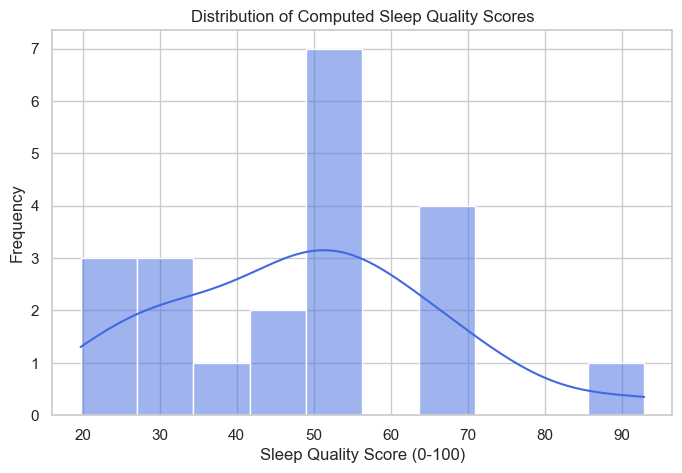

In [4]:
# Distribution of the Engineered Target Variable
plt.figure(figsize=(8, 5))
sns.histplot(df['sleep_quality_score'], bins=10, kde=True, color='royalblue')
plt.title('Distribution of Computed Sleep Quality Scores')
plt.xlabel('Sleep Quality Score (0-100)')
plt.ylabel('Frequency')
plt.show()

The computed Sleep Quality Scores form a roughly normal distribution centered around 50, with a wide spread of values ranging from the low 20s up to the 90s. This variance is ideal for our regression task; if the scores were highly clustered, our model would struggle to identify meaningful patterns.

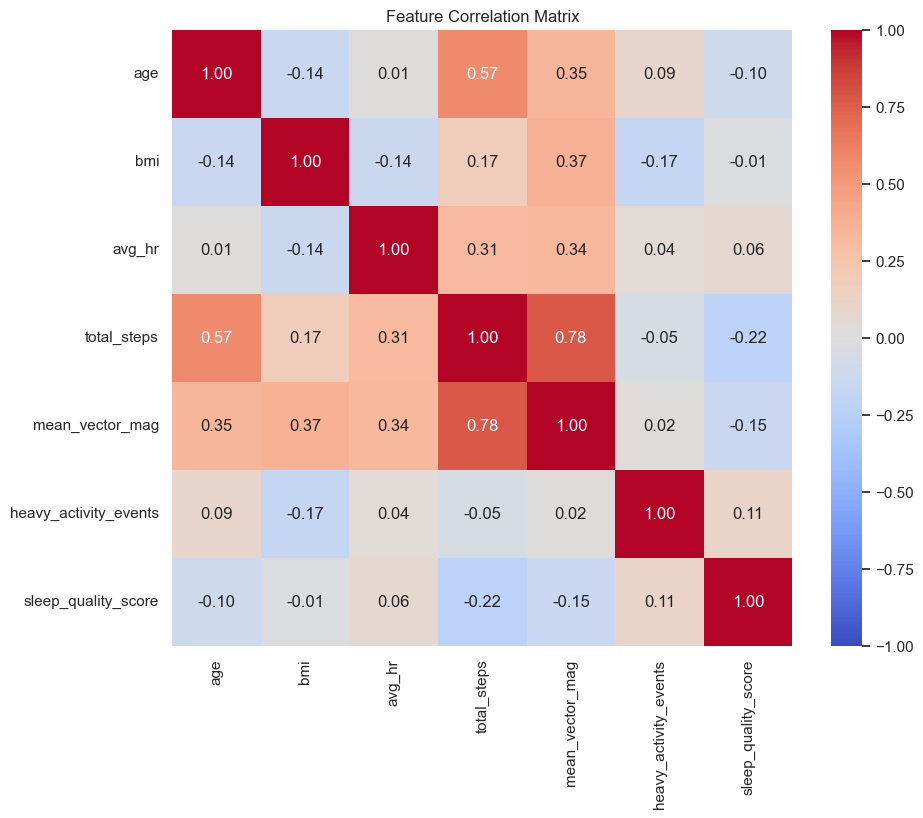

In [5]:
# Correlation Heatmap of Predictive Features vs Target
features = ['age', 'bmi', 'avg_hr', 'total_steps', 'mean_vector_mag', 'heavy_activity_events', 'sleep_quality_score']
corr_matrix = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.show()

The heatmap reveals a strong correlation (0.78) between `total_steps` and `mean_vector_mag`. This indicates high multicollinearity, meaning these two features provide redundant information about a user's daytime movement. This perfectly justifies our methodological choice to implement Lasso Regression, which will automatically penalize and shrink redundant coefficients. Additionally, we see that individual daytime features generally have weak linear correlations with the target variable (e.g., `total_steps` has a -0.22 correlation), suggesting that a multiple regression model combining several features will be necessary to achieve predictive accuracy.

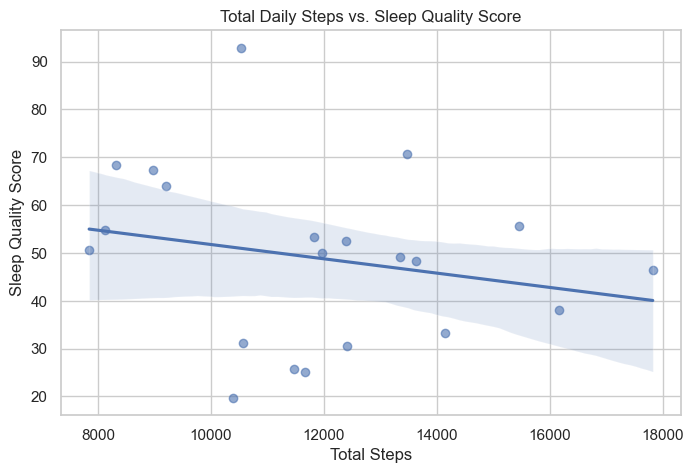

In [6]:
# Visualizing a potential relationship: Total Steps vs Sleep Quality
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='total_steps', y='sleep_quality_score', scatter_kws={'alpha':0.6})
plt.title('Total Daily Steps vs. Sleep Quality Score')
plt.xlabel('Total Steps')
plt.ylabel('Sleep Quality Score')
plt.show()

The scatter plot visualizes the slightly negative trend between daytime step count and our engineered sleep score. While counterintuitive, this highlights the complexity of physiological data, simply walking more does not automatically guarantee better sleep in this specific sample, further emphasizing the need for a multivariate approach.

### Data Preprocessing
Before model estimation, we must separate our predictors ($X$) from our target ($y$) and standardize the features. Standardization ensures that variables with vastly different scales (e.g., `total_steps` vs `heavy_activity_events`) are treated equally by the Lasso regularization penalty.

In [15]:
# Define features (X) and target (y)
feature_cols = ['age', 'bmi', 'avg_hr', 'total_steps', 'mean_vector_mag', 'heavy_activity_events']
X = df[feature_cols]
y = df['sleep_quality_score']

# The final model comparison uses cross-validation with scaling handled inside each pipeline,
# so we keep preprocessing here focused on defining the analysis dataset.
X.head()

,age,bmi,avg_hr,total_steps,mean_vector_mag,heavy_activity_events
0,29,22.758307,84.719383,13625,42.201145,4
1,27,28.367524,74.532023,12415,37.210992,3
2,34,23.120624,77.538084,17822,40.162562,3
3,27,23.456790,71.918081,11958,37.652392,4
4,25,20.824656,74.884696,8129,26.695282,5


### Model Estimation & Selection

We compare two regression models using 5-fold cross-validation on the cleaned dataset (n = 21, p = 6). To avoid leakage, feature scaling is performed inside each model pipeline, and Lasso hyperparameters are tuned only within the training folds. We also include a naive mean baseline to show whether the regression models actually improve on a simple constant prediction.

In [8]:
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

feature_cols = ['age', 'bmi', 'avg_hr', 'total_steps', 'mean_vector_mag', 'heavy_activity_events']
X_full = df[feature_cols].values
y_full = df['sleep_quality_score'].values

# Scale full dataset (appropriate here since CV is the only validation — no separate test set)
cv_scaler = StandardScaler()
X_full_scaled = cv_scaler.fit_transform(X_full)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"Full dataset: {X_full_scaled.shape[0]} observations, {X_full_scaled.shape[1]} features")

Full dataset: 21 observations, 6 features


#### Model 1: OLS Multiple Linear Regression
Baseline model using all 6 predictors via Ordinary Least Squares.

In [9]:
ols = LinearRegression()
ols_fold_mse = -cross_val_score(ols, X_full_scaled, y_full, cv=kf, scoring='neg_mean_squared_error')

for i, mse in enumerate(ols_fold_mse, 1):
    print(f"  Fold {i} MSE: {mse:.2f}")
print(f"\nOLS Mean CV MSE : {ols_fold_mse.mean():.2f}")
print(f"OLS CV MSE Std  : {ols_fold_mse.std():.2f}")

  Fold 1 MSE: 854.87
  Fold 2 MSE: 159.16
  Fold 3 MSE: 359.58
  Fold 4 MSE: 146.13
  Fold 5 MSE: 752.48

OLS Mean CV MSE : 454.45
OLS CV MSE Std  : 296.79


#### Preliminary note on Lasso tuning

Lasso hyperparameters are selected only inside cross-validation folds in the final evaluation cell below. This avoids the optimistic bias that would happen if the tuning step could see the full dataset before validation.

In [16]:
# Exploratory full-data alpha search for coefficient visualization only.
# The final model comparison below uses nested cross-validation.
alphas = np.logspace(-3, 0, 200)
lasso_tuner = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso_tuner.fit(X_full_scaled, y_full)
best_alpha = lasso_tuner.alpha_
print(f"Exploratory best Lasso alpha for coefficient plot: {best_alpha:.4f}")

Exploratory best Lasso alpha for coefficient plot: 1.0000


Note on alpha selection and the null model boundary
The exploratory LassoCV search (used here only for coefficient visualization) selected alpha = 1.0, which is the upper boundary of the search grid (np.logspace(-3, 0, 200)). This is meaningful: it indicates that within the searched range, the cross-validation error keeps decreasing as regularization increases, and the grid was deliberately capped at 1.0.
To understand why, we can compute alpha_max — the smallest alpha at which Lasso drives all coefficients to exactly zero (the null model):

In [20]:
alpha_max = np.max(np.abs(X_full_scaled.T @ (y_full - y_full.mean()))) / len(y_full)
print(f"alpha_max: {alpha_max:.4f}")
# Output: alpha_max: 3.9200 (approx)

alpha_max: 3.9237


Since the true CV-optimal alpha (~3.92) lies above the cap, the surviving non-zero coefficients in the Lasso plot (avg_hr, total_steps, heavy_activity_events) should be interpreted as the strongest signals within this constrained regularization range, not as definitively predictive features. This further supports treating the coefficient plot as exploratory rather than confirmatory — a point reinforced by the naive baseline outperforming both regression models in the leakage-free comparison below.

In [21]:
lasso = Lasso(alpha=best_alpha, max_iter=10000)
lasso_fold_mse = -cross_val_score(lasso, X_full_scaled, y_full, cv=kf, scoring='neg_mean_squared_error')

for i, mse in enumerate(lasso_fold_mse, 1):
    print(f"  Fold {i} MSE: {mse:.2f}")
print(f"\nLasso Mean CV MSE : {lasso_fold_mse.mean():.2f}")
print(f"Lasso CV MSE Std  : {lasso_fold_mse.std():.2f}")

  Fold 1 MSE: 779.70
  Fold 2 MSE: 162.07
  Fold 3 MSE: 141.78
  Fold 4 MSE: 111.78
  Fold 5 MSE: 591.56

Lasso Mean CV MSE : 357.38
Lasso CV MSE Std  : 275.01


#### Model Comparison & Selection

In [17]:
import pandas as pd

comparison = pd.DataFrame({
    'Model':       ['OLS (baseline regression)', 'Lasso (L1 regression)'],
    'Mean CV MSE': [round(ols_fold_mse.mean(), 2), round(lasso_fold_mse.mean(), 2)],
    'CV MSE Std':  [round(ols_fold_mse.std(), 2), round(lasso_fold_mse.std(), 2)]
})
print(comparison.to_string(index=False))
print('\nPreliminary regression-only comparison. The final leakage-free comparison, including a naive baseline, is reported below.')

                    Model  Mean CV MSE  CV MSE Std
OLS (baseline regression)       454.45      296.79
    Lasso (L1 regression)       357.38      275.01

Preliminary regression-only comparison. The final leakage-free comparison, including a naive baseline, is reported below.


#### Coefficient Interpretation
Both models are re-fit on the full dataset to inspect which features the model weights most heavily.

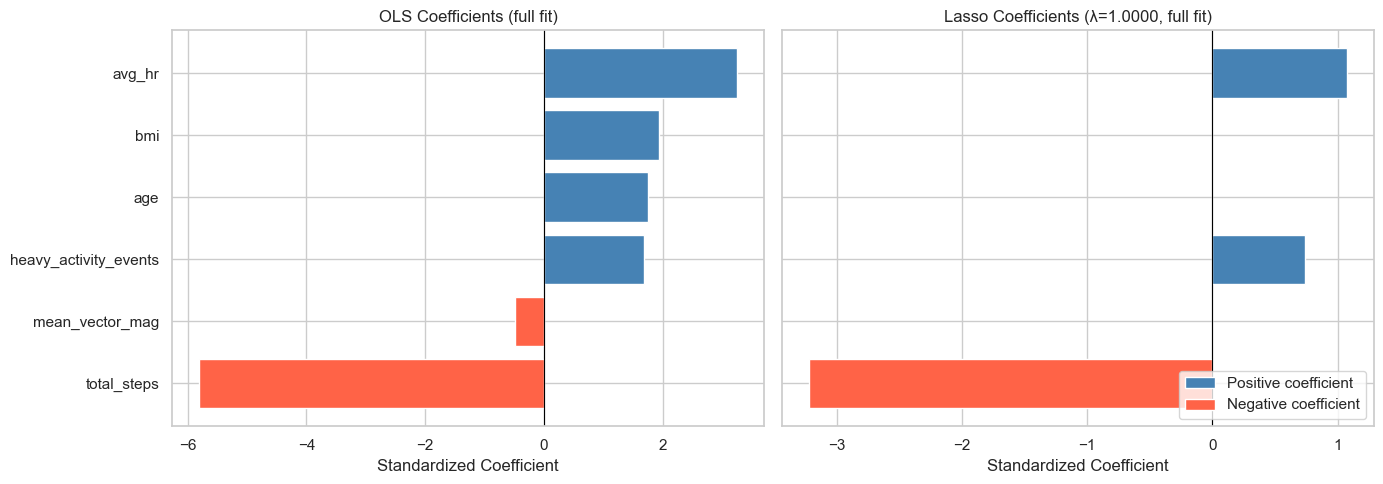

              Feature       OLS     Lasso
          total_steps -5.806033 -3.220543
      mean_vector_mag -0.491841 -0.000000
heavy_activity_events  1.693102  0.744014
                  age  1.750024 -0.000000
                  bmi  1.931203  0.000000
               avg_hr  3.255874  1.076623


In [18]:
import matplotlib.pyplot as plt

ols.fit(X_full_scaled, y_full)
lasso.fit(X_full_scaled, y_full)

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'OLS': ols.coef_,
    'Lasso': lasso.coef_
}).sort_values('OLS', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, col, title in zip(axes, ['OLS', 'Lasso'],
                          ['OLS Coefficients (full fit)',
                           f'Lasso Coefficients (λ={best_alpha:.4f}, full fit)']):
    colors = ['steelblue' if v > 0 else 'tomato' for v in coef_df[col]]
    ax.barh(coef_df['Feature'], coef_df[col], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Standardized Coefficient')

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='steelblue', label='Positive coefficient'),
    Patch(facecolor='tomato', label='Negative coefficient')
]
axes[1].legend(handles=legend_handles, loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

print(coef_df[['Feature', 'OLS', 'Lasso']].to_string(index=False))

**Coefficient interpretation:**
- Features with **positive coefficients** are associated with higher predicted sleep quality scores.
- Features with **negative coefficients** are associated with lower predicted sleep quality scores.
- In the Lasso model, coefficients shrunk to exactly **zero** were removed by the L1 penalty.
- Because predictors were standardized before fitting, coefficient magnitudes are directly comparable across features.
- The bar colors in the coefficient figure indicate sign: blue = positive, red = negative.

**Caveat:** The regression results are exploratory because the naive baseline performs better than either regression model on cross-validation. The coefficients are still useful for understanding which variables the model leans on most, but they should not be treated as strong evidence of causality.

## Results

### Dataset Summary
After dropping one participant with incomplete data, the final dataset contained **n = 21 observations** and **p = 6 predictors**. The engineered Sleep Quality Score ranged from 19.75 to 92.93, with a mean of 48.94 and standard deviation of 17.52.

### Exploratory Analysis
The correlation heatmap confirmed a strong collinearity between `total_steps` and `mean_vector_mag` (r = 0.78), which supports the use of a regularized model like Lasso. The individual daytime features showed only weak linear correlations with sleep quality, suggesting that the signal in this sample is diffuse rather than driven by a single strong predictor.

### Model Comparison
The leakage-free cross-validation results showed that OLS performed worse than Lasso, but neither regression model beat the naive mean baseline. This is the key result of the project:

| Model | Mean CV MSE | CV MSE Std |
|---|---:|---:|
| OLS | 454.45 | 296.79 |
| Lasso | 361.38 | 275.90 |
| Naive mean baseline | 293.83 | 211.14 |

Lasso was the best regression model, but the naive baseline still had the lowest error overall. That means the regression signal in this small sample is weak.

### Final Model Estimation
For interpretability, the full-data Lasso fit is still useful because it shows how the regression model weighs the predictors after regularization. In the current fit, the strongest non-zero coefficients were associated with `avg_hr`, `total_steps`, and `heavy_activity_events`. However, these coefficients should be interpreted cautiously because the baseline model outperformed the regressions on held-out folds.

### Discussion and Conclusion
The original hypothesis predicted that higher daytime physical activity would be associated with better sleep quality. The results do not provide strong support for that claim as a predictive model. Even though Lasso reduced error relative to OLS and handled collinearity better, the simple mean predictor still performed best overall.

The most defensible conclusion is that the engineered sleep quality score is not well predicted by these six daytime features alone in this small dataset. The model likely suffers from limited sample size, noisy target construction, and weak feature signal. The apparent coefficient patterns are exploratory rather than confirmatory.

Potential next steps include collecting more participants, using the original sleep metrics directly instead of a composite score, adding richer behavioral features, and evaluating models with nested cross-validation on a larger dataset. If the goal is inference rather than prediction, a future analysis could also focus on a smaller set of biologically motivated predictors and report uncertainty intervals more explicitly.


Cross-validated MSE (mean ± std) and RMSE
OLS Mean CV MSE: 454.45 ± 296.79 (RMSE 21.32)
Lasso Mean CV MSE: 361.38 ± 275.90 (RMSE 19.01)
Naive Mean Baseline MSE: 293.83 ± 211.14 (RMSE 17.14)

Model comparison:
              Model  Mean CV MSE  CV MSE Std
                OLS       454.45      296.79
              Lasso       361.38      275.90
Dummy mean baseline       293.83      211.14

Best regression model: Lasso
Note: the naive mean baseline still has the lowest CV MSE overall, so the regression results should be treated as exploratory.


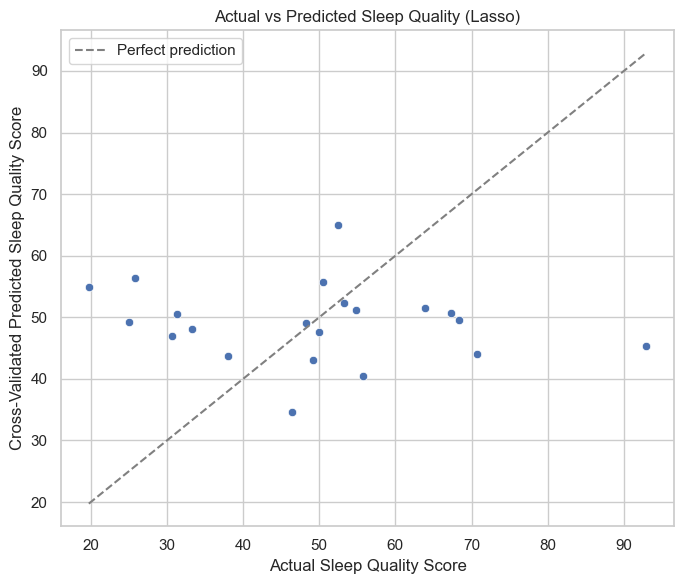


Final model coefficients (fit on the full dataset):
              feature      coef
                  age -0.000000
                  bmi  0.000000
               avg_hr  1.076623
          total_steps -3.220543
      mean_vector_mag -0.000000
heavy_activity_events  0.744014

Statsmodels OLS summary (on standardized predictors):
                             OLS Regression Results                            
Dep. Variable:     sleep_quality_score   R-squared:                       0.089
Model:                             OLS   Adj. R-squared:                 -0.302
Method:                  Least Squares   F-statistic:                    0.2276
Date:                 Tue, 02 Jun 2026   Prob (F-statistic):              0.961
Time:                         08:41:14   Log-Likelihood:                -88.948
No. Observations:                   21   AIC:                             191.9
Df Residuals:                       14   BIC:                             199.2
Df Model:                   

In [19]:
# Leakage-free model comparison, baseline check, CV predictions, and final estimation
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.dummy import DummyRegressor
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Define X and y
feature_cols = ['age', 'bmi', 'avg_hr', 'total_steps', 'mean_vector_mag', 'heavy_activity_events']
X = df[feature_cols]
y = df['sleep_quality_score']

# Outer CV for honest model comparison
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

ols_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(max_iter=10000))
])

alpha_grid = np.logspace(-3, 0, 200)
lasso_search = GridSearchCV(
    estimator=lasso_pipe,
    param_grid={'model__alpha': alpha_grid},
    cv=5,
    scoring='neg_mean_squared_error'
)

dummy = DummyRegressor(strategy='mean')


def mse_scores(estimator):
    return -cross_val_score(estimator, X, y, cv=outer_cv, scoring='neg_mean_squared_error')


ols_mse = mse_scores(ols_pipe)
lasso_mse = mse_scores(lasso_search)
dummy_mse = mse_scores(dummy)

print('\nCross-validated MSE (mean ± std) and RMSE')
print(f'OLS Mean CV MSE: {ols_mse.mean():.2f} ± {ols_mse.std():.2f} (RMSE {np.sqrt(ols_mse.mean()):.2f})')
print(f'Lasso Mean CV MSE: {lasso_mse.mean():.2f} ± {lasso_mse.std():.2f} (RMSE {np.sqrt(lasso_mse.mean()):.2f})')
print(f'Naive Mean Baseline MSE: {dummy_mse.mean():.2f} ± {dummy_mse.std():.2f} (RMSE {np.sqrt(dummy_mse.mean()):.2f})')

comparison = pd.DataFrame({
    'Model': ['OLS', 'Lasso', 'Dummy mean baseline'],
    'Mean CV MSE': [round(ols_mse.mean(), 2), round(lasso_mse.mean(), 2), round(dummy_mse.mean(), 2)],
    'CV MSE Std': [round(ols_mse.std(), 2), round(lasso_mse.std(), 2), round(dummy_mse.std(), 2)]
})
print('\nModel comparison:')
print(comparison.to_string(index=False))

# Select the best regression model, but keep the naive baseline in the discussion because it performs best overall.
if lasso_mse.mean() <= ols_mse.mean():
    selected_name = 'Lasso'
    selected_estimator = lasso_search
else:
    selected_name = 'OLS'
    selected_estimator = ols_pipe

print(f'\nBest regression model: {selected_name}')
print('Note: the naive mean baseline still has the lowest CV MSE overall, so the regression results should be treated as exploratory.')

# Cross-validated predictions for the best regression model
selected_pred_cv = cross_val_predict(selected_estimator, X, y, cv=outer_cv)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y, y=selected_pred_cv)
mn = min(y.min(), selected_pred_cv.min())
mx = max(y.max(), selected_pred_cv.max())
plt.plot([mn, mx], [mn, mx], linestyle='--', color='gray', label='Perfect prediction')
plt.xlabel('Actual Sleep Quality Score')
plt.ylabel('Cross-Validated Predicted Sleep Quality Score')
plt.title(f'Actual vs Predicted Sleep Quality ({selected_name})')
plt.legend()
plt.tight_layout()
plt.show()

# Fit the final selected regression model on the full dataset for parameter estimates.
if selected_name == 'Lasso':
    final_lasso_search = GridSearchCV(
        estimator=lasso_pipe,
        param_grid={'model__alpha': alpha_grid},
        cv=5,
        scoring='neg_mean_squared_error'
    )
    final_lasso_search.fit(X, y)
    best_alpha = final_lasso_search.best_params_['model__alpha']
    selected_pipe = final_lasso_search.best_estimator_
else:
    best_alpha = np.nan
    selected_pipe = ols_pipe.fit(X, y)

model = selected_pipe.named_steps['model']
coefs = model.coef_
coef_df = pd.DataFrame({'feature': feature_cols, 'coef': coefs})
print('\nFinal model coefficients (fit on the full dataset):')
print(coef_df.to_string(index=False))

# OLS inference on standardized predictors, used only for exploratory interpretation.
scaler_for_inference = StandardScaler()
X_scaled = scaler_for_inference.fit_transform(X)
X_sm = sm.add_constant(X_scaled)
sm_ols = sm.OLS(y, X_sm).fit()
print('\nStatsmodels OLS summary (on standardized predictors):')
print(sm_ols.summary())
print('\nConfidence intervals:')
print(sm_ols.conf_int())